In [5]:
from pathlib import Path
REPO_ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "absorption_paper_source_data").is_dir())
import sys
from pathlib import Path

# Explicit project root
project_root = Path(str(REPO_ROOT))

# Add to sys.path if not already present
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"[path] Added project root: {project_root}")
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import pandas as pd
import numpy as np
import torch
# =========================================================
# FORCE ARIAL GLOBALLY
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Arial"
plt.rcParams["mathtext.it"] = "Arial:italic"
plt.rcParams["mathtext.bf"] = "Arial:bold"

import os
import re
import pandas as pd
import numpy as np
import torch

from ase.build import minimize_rotation_and_translation
from ase import Atoms
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression

import matplotlib.cm as cm
import matplotlib.colors as mc
import colorsys


In [6]:

def get_loss(loss_name):
    """
    Get loss function from loss name
    """
    loss_dict = {
        "rbragg_abs": rbragg_abs,
    }
    if loss_name not in loss_dict:
        raise ValueError(f"Loss name {loss_name} not found")
    return loss_dict[loss_name]


def rbragg_abs(sim_intensities, exp_intensities, sigmas=None):
    """
    Compute the Rbragg metric using only reflections where I_exp > 3 * sigma.

    R = sum(|sqrt(I_pred) - sqrt(I_exp)|) / sum(sqrt(I_exp))

    Params:
    - sim_intensities: torch.tensor of predicted intensities
    - exp_intensities: torch.tensor of experimental intensities
    - sigmas: torch.tensor of experimental uncertainties (same shape as intensities)

    Returns:
    - R(obs): torch.tensor of R(obs) value
    """
    if sigmas is None:
        raise ValueError("sigmas must be provided to apply I > 3*sigma filter.")

    
    sqrt_exp = exp_intensities.sqrt()
    sqrt_sim = sim_intensities.sqrt()
    num = torch.sum(torch.abs(sqrt_exp - sqrt_sim), dim=-1)
    denom = torch.sum(sqrt_exp, dim=-1)
    return num / denom

def initialize_scaling_factor(
    exp_intensities, simulated_intensities, sigmas, r_value_method="rbragg_abs"
    ):
    """
    Initialize scaling factor to minimize R value
    Params:
    - scaling_factor: scaling factor for each rotation
    - exp_intensities: experimental intensities
    - simulated_intensities: simulated intensities
    - sigmas: experimental sigmas
    - r_value_method: whether to use wRbragg, rbragg_abs, or rbragg_squared
    Returns:
    - scaling_factor: scaling factor for each rotation
    """
    start = 0.02
    end = 2
    num_points = 100
    grid_points = torch.linspace(start, end, num_points, device=exp_intensities.device)
    exp_sum = torch.sum(exp_intensities)
    sim_sum = torch.sum(simulated_intensities)
    scaled_intensities = (
        grid_points.view(-1, 1) * (exp_sum / sim_sum) * simulated_intensities
    )
    losses = get_loss(r_value_method)(scaled_intensities, exp_intensities, sigmas)
    min_value, min_idx = torch.min(losses, dim=0)
    scaling_factor = grid_points[min_idx]

    return scaling_factor, min_value

def get_hkls_above_3sigma(cif_file, orientations=None):
    with open(cif_file, "r") as f:
        lines = f.readlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("loop_") and "_refln_index_h" in "".join(lines[i+1:i+10]):
            start_idx = i
            break
    if start_idx is None:
        raise RuntimeError("Could not find reflection loop in CIF file")

    headers = []
    i = start_idx + 1
    while lines[i].strip().startswith("_refln"):
        headers.append(lines[i].strip())
        i += 1

    data_lines = []
    for line in lines[i:]:
        if re.match(r"^\s*[-0-9]", line):
            data_lines.append(line.strip().split())
        else:
            break

    df = pd.DataFrame(data_lines, columns=headers)
    df = df.apply(pd.to_numeric, errors="ignore")

    if orientations is not None:
        df = df[df["_refln_zone_axis_id"].isin(np.atleast_1d(orientations))]

    mask = df["_refln_intensity_meas"] > 3 * df["_refln_intensity_sigma"]
    hkls = {
        (int(h), int(k), int(l))
        for h, k, l, m in zip(
            df["_refln_index_h"], df["_refln_index_k"], df["_refln_index_l"], mask
        ) if m
    }

    print(f"[INFO] Found {len(hkls)} HKLs above 3σ for orientations={orientations}")
    return hkls


In [7]:
def compare_and_compute_R(no_abs_csv, abs_csv, cutoff=1e-20,
                          save_pointwise_path=None,
                          save_summary_path=None,
                          save_rvals_path=None,
                          hkls_filter=None):
    print(f"[LOAD] no_abs={no_abs_csv}, abs={abs_csv}")

    df_no_abs = pd.read_csv(no_abs_csv).rename(columns={"intensity": "I_no_abs"})
    df_abs    = pd.read_csv(abs_csv).rename(columns={"intensity": "I_abs"})
    print(f"[INFO] Shapes: no_abs={df_no_abs.shape}, abs={df_abs.shape}")

    df = pd.merge(df_no_abs, df_abs, on=["h", "k", "l", "tilt_angle"], suffixes=("_no_abs", "_abs"))
    print(f"[INFO] After merge: {df.shape}")

    if hkls_filter is not None:
        before = len(df)
        df = df[df.apply(lambda r: (int(r.h), int(r.k), int(r.l)) in hkls_filter, axis=1)]
        after = len(df)
        print(f"[FILTER] Applied 3σ HKL filter → kept {after}/{before}")

    before = len(df)
    df = df[(df["I_no_abs"] > cutoff) & (df["I_abs"] > cutoff)].copy()
    after = len(df)
    print(f"[FILTER] Applied cutoff={cutoff}, kept {after}/{before} rows")

    if df.empty:
        print("[WARN] Empty dataframe after filtering, returning NaN")
        return float("nan"), pd.DataFrame(), float("nan")

    all_pointwise, all_summary = [], []
    for (h, k, l), df_sel in df.groupby(["h", "k", "l"]):
        y_no_abs = df_sel["I_no_abs"].values
        y_abs    = df_sel["I_abs"].values
        x_vals   = df_sel["tilt_angle"].values

        no_abs_int = np.sum(y_no_abs)
        abs_int    = np.sum(y_abs)
        percent_diff_integrated = 100 * abs(no_abs_int - abs_int) / max(no_abs_int, abs_int)

        all_summary.append(pd.DataFrame([{
            "HKL": f"({h},{k},{l})",
            "Integrated_no_abs": no_abs_int,
            "Integrated_abs": abs_int,
            "Δ Integrated (%)": percent_diff_integrated
        }]))

        all_pointwise.append(pd.DataFrame({
            "HKL": [f"({h},{k},{l})"] * len(x_vals),
            "tilt_angle": x_vals,
            "I_no_abs": y_no_abs,
            "I_abs": y_abs,
            "ΔI": y_no_abs - y_abs,
            "ΔI_percent": 100 * (y_no_abs - y_abs) / np.maximum(y_no_abs, y_abs)
        }))

    df_pointwise_all = pd.concat(all_pointwise, ignore_index=True)
    df_summary_all   = pd.concat(all_summary, ignore_index=True)
    print(f"[INFO] Summary rows={len(df_summary_all)}, Pointwise rows={len(df_pointwise_all)}")

    if save_pointwise_path and not df_pointwise_all.empty:
        df_pointwise_all.to_csv(save_pointwise_path, index=False)
    if save_summary_path and not df_summary_all.empty:
        df_summary_all.to_csv(save_summary_path, index=False)

    exp_ints = torch.tensor(df_summary_all["Integrated_no_abs"].values, dtype=torch.float32)
    sim_ints = torch.tensor(df_summary_all["Integrated_abs"].values,    dtype=torch.float32)
    print(f"[DEBUG] exp_sum={exp_ints.sum().item()}, sim_sum={sim_ints.sum().item()}, n={len(exp_ints)}")

    if len(exp_ints) == 0 or exp_ints.sum().item() == 0 or sim_ints.sum().item() == 0:
        print("[WARN] Zero or empty intensities → returning NaN")
        return float("nan"), pd.DataFrame(), float("nan")

    scaling_factor, R_val_global = initialize_scaling_factor(
        exp_intensities=exp_ints,
        simulated_intensities=sim_ints,
        sigmas=torch.ones_like(exp_ints),
        r_value_method="rbragg_abs"
    )
    print(f"[RESULT] Global R={R_val_global.item():.6f}, Scale={scaling_factor.item():.6f}")

    results = []
    for tilt in sorted(df_pointwise_all["tilt_angle"].unique()):
        df_sel = df_pointwise_all[df_pointwise_all["tilt_angle"] == tilt]
        exp_ints = torch.tensor(df_sel["I_no_abs"].values, dtype=torch.float32)
        sim_ints = torch.tensor(df_sel["I_abs"].values,    dtype=torch.float32)

        if exp_ints.sum().item() == 0 or sim_ints.sum().item() == 0:
            print(f"[WARN] Zero intensity at tilt={tilt}")
            continue

        scaling_factor, R_val = initialize_scaling_factor(
            exp_intensities=exp_ints,
            simulated_intensities=sim_ints,
            sigmas=torch.ones_like(exp_ints),
            r_value_method="rbragg_abs"
        )
        results.append({
            "tilt_angle": tilt,
            "R_value": R_val.item(),
            "Scale": scaling_factor.item(),
            "Num_reflections": len(df_sel)
        })

    df_rvals_tilt = pd.DataFrame(results)
    avg_R = df_rvals_tilt["R_value"].mean(skipna=True) if not df_rvals_tilt.empty else float("nan")
    print(f"[RESULT] Avg R across tilts={avg_R}")

    if save_rvals_path and not df_rvals_tilt.empty:
        df_rvals_tilt.to_csv(save_rvals_path, index=False)

    return R_val_global.item(), df_rvals_tilt, avg_R

# ------------------------------------------------------------
# Collect paired files and run R computation (note hkls_filter pass-through)
# ------------------------------------------------------------
def process_and_collect(folder, cutoff=1e-4, orientations=None, hkls_filter=None):
    folder = Path(folder)
    files = [f for f in folder.glob("*rocking_curves.csv") if f.is_file()]

    orient_map = {}
    for f in files:
        m_rot = re.search(r"rotation_(\d+)", f.name)
        m_thick = re.search(r"thickness_(\d+)", f.name)
        if not (m_rot and m_thick):
            continue
        rotation = int(m_rot.group(1))
        thickness = int(m_thick.group(1))

        if orientations and rotation not in orientations:
            continue

        abs_type = "param" if "param" in f.name else "no_abs"
        orient_map.setdefault(rotation, {}).setdefault(thickness, {})[abs_type] = f

    results = []
    for rot, thickmap in sorted(orient_map.items()):
        for thickness, pair in sorted(thickmap.items()):
            if "no_abs" in pair and "param" in pair:
                global_R, df_rvals_tilt, avg_R = compare_and_compute_R(
                    no_abs_csv=pair["no_abs"],
                    abs_csv=pair["param"],
                    cutoff=cutoff,
                    hkls_filter=hkls_filter,
                )
                results.append({
                    "Rotation": rot,
                    "Thickness": thickness,
                    "Global_R": global_R,
                    "Avg_Tilt_R": avg_R,
                    "Std_Tilt_R": df_rvals_tilt["R_value"].std(skipna=True) if not df_rvals_tilt.empty else float("nan"),
                })

    if not results:
        return pd.DataFrame(columns=["Rotation", "Thickness", "Global_R", "Avg_Tilt_R", "Std_Tilt_R"])

    return pd.DataFrame(results).sort_values(["Rotation", "Thickness"])

# ------------------------------------------------------------
# Plotting (unchanged except it now uses updated process_and_collect)
# ------------------------------------------------------------
def plot_global_and_tilt_multiple(
    folders, cutoff=1e-4, save_summary=None, params=None,
    orientations=None, mode="both", use_shaded_errors=False,
    cif_exp=None
):
    results_map = {}
    hkls_filter = get_hkls_above_3sigma(cif_exp, orientations=orientations) if cif_exp else None

    for folder in folders:
        df = process_and_collect(folder, cutoff=cutoff, orientations=orientations, hkls_filter=hkls_filter)
        results_map[os.path.basename(folder)] = df

    if all(df.empty for df in results_map.values()):
        return results_map

    plt.figure(figsize=(12, 9))
    style_handles = []

    for i, (label, df) in enumerate(results_map.items()):
        if df.empty:
            continue
        for j, (rot, df_rot) in enumerate(df.groupby("Rotation")):
            x_nm = (df_rot["Thickness"] / 10.0).values.reshape(-1, 1)

            if mode in ("tilt", "both"):
                y = (100 * df_rot["Avg_Tilt_R"]).values
                err = (df_rot["Std_Tilt_R"] * 100).values
                plt.scatter(x_nm, y, color="cornflowerblue", s=40, marker="o")
                style_handles.append(Line2D([0], [0], marker="o", color="none",  markeredgecolor="none",
                                            markerfacecolor="cornflowerblue", markersize=12,
                                            label=r"Per-Tilt $R_1$"))
                plt.errorbar(x_nm.ravel(), y, yerr=err, fmt="none", elinewidth=1.0,
                             capsize=3, color="cornflowerblue", alpha=0.6)
                model = LinearRegression().fit(x_nm, y)
                slope, intercept = model.coef_[0], model.intercept_
                x_fit = np.linspace(x_nm.min(), x_nm.max(), 200).reshape(-1, 1)
                y_fit = model.predict(x_fit)
                plt.plot(x_fit, y_fit, color="cornflowerblue", linewidth=2.0, linestyle="--")
               
                                            

            if mode in ("global", "both"):
                y = (100 * df_rot["Global_R"]).values
                plt.scatter(x_nm, y, color="darkblue", s=40, marker="o")
                style_handles.append(Line2D([0], [0], marker="o", color="none",
                                            markerfacecolor="darkblue", markeredgecolor="none", markersize=12,
                                            label=r"Integrated Intensity $R_1$"))
                model = LinearRegression().fit(x_nm, y)
                slope, intercept = model.coef_[0], model.intercept_
                x_fit = np.linspace(x_nm.min(), x_nm.max(), 200).reshape(-1, 1)
                y_fit = model.predict(x_fit)
                plt.plot(x_fit, y_fit, color="darkblue", linewidth=2.0)
                
    plt.xlabel("Thickness (nm)", fontsize=45)
    plt.ylabel(r"Residual ($R_1$) (%)", fontsize=45)
    plt.xticks([0, 100, 200], fontsize=45)
    plt.gca().set_xticks(np.arange(0, 251, 25), minor=True)
    plt.tick_params(axis="both", which="major", length=5, width=2.4)
    plt.tick_params(axis="both", which="minor", length=5, width=1.8)

    plt.yticks([0,5,10,15,20], fontsize=45)
    
    plt.xlim(0, 250)
    plt.ylim(0, 20)
    plt.legend(
    handles=style_handles,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.95),
    borderaxespad=0,
    borderpad=0,
    handlelength=0.7,
    handletextpad=0.5,
    fontsize=39)

    plt.tight_layout()
    plt.show()
    
  

    if save_summary:
        for label, df in results_map.items():
            out = Path(save_summary).with_name(f"{label}_{Path(save_summary).name}")
            df.to_csv(out, index=False)

    return results_map


/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_11923/593981553.py:92: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


[INFO] Found 63 HKLs above 3σ for orientations=[1]
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/no_abs_rotation_1_thickness_100_rocking_curves.csv, abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/param_rotation_1_thickness_100_rocking_curves.csv
[INFO] Shapes: no_abs=(27240, 7), abs=(27240, 7)
[INFO] After merge: (27240, 10)
[FILTER] Applied 3σ HKL filter → kept 1740/27240
[FILTER] Applied cutoff=1e-25, kept 1441/1740 rows
[INFO] Summary rows=29, Pointwise rows=1441
[DEBUG] exp_sum=1.7154392004013062, sim_sum=1.5303670167922974, n=29
[RESULT] Global R=0.006369, Scale=1.000000
[RESULT] Avg R across tilts=0.012975012922349075
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/no_abs_rotation_1_thickness_181_rocking_curves.csv, abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/param_rotation_1_thickness_181_rocking_cu

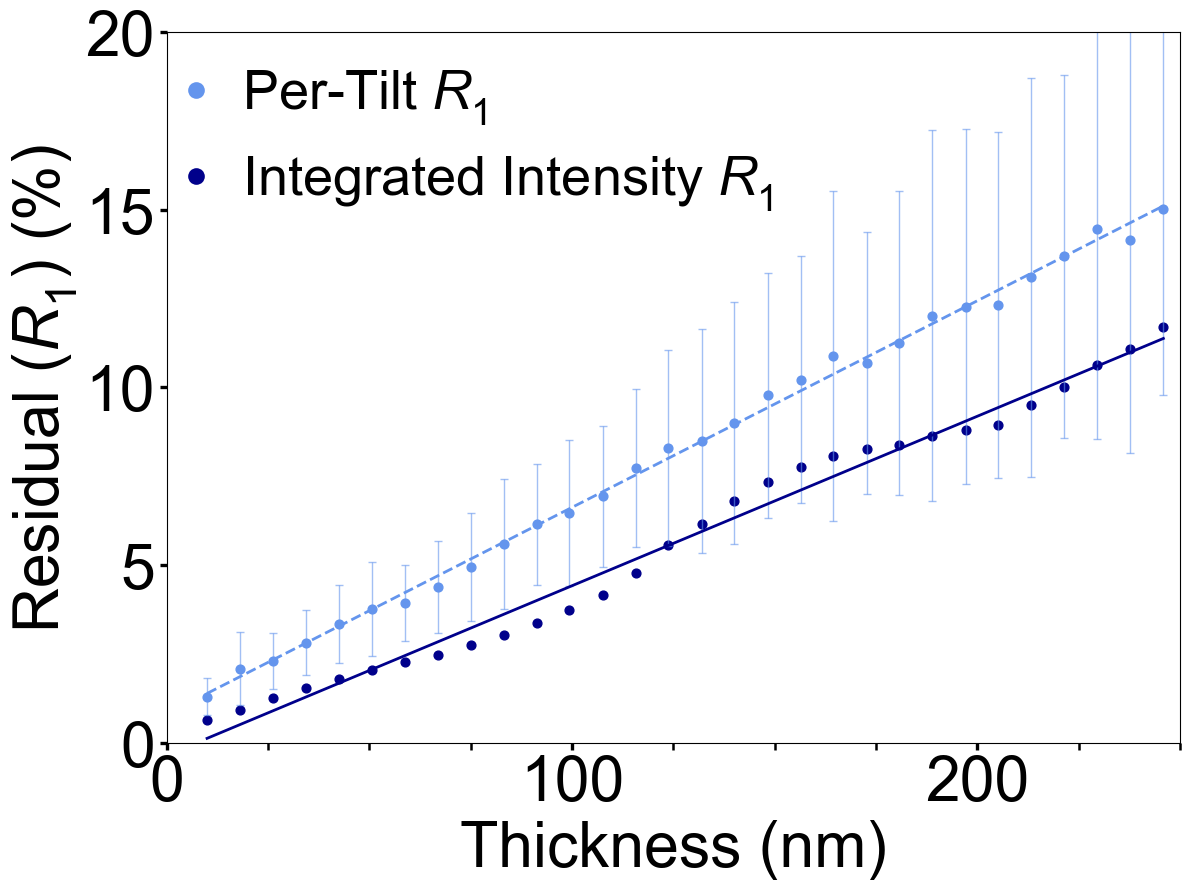

In [8]:
results_map = plot_global_and_tilt_multiple(
    [str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset")],
    cutoff=1e-25,
    orientations=[1],
    mode="both",
    cif_exp=str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/CsPbBr_P67-crot-050_dyn.cif_pets"),
)


In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import os

def plot_global_only(
    folders,
    cutoff=1e-8,
    save_summary=None,
    params=None,
    orientations=None,
    mode="global",      # "global", "tilt", or "both"
    use_shaded_errors=False,
    orientation_labels=None,   # dict {rotation_number: "label"}
    g_cutoff=10,               # max |g| in Å⁻¹
    hkls_filter=None           # set of HKL tuples to keep (e.g., above I/σ threshold)
):
    """
    Plot Integrated R (scatter + linear fit) for multiple orientations.
    - Optional g-vector cutoff.
    - Optional HKL filter (e.g., I/sigma > 3 from CIF).
    """
    results_map = {}
    for folder in folders:
        df = process_and_collect(folder, cutoff=cutoff, orientations=orientations)

        # g-vector cutoff
        if "G-vector Length" in df.columns:
            before = len(df)
            df = df[df["G-vector Length"] <= g_cutoff].copy()
            after = len(df)
            print(f"[info] {os.path.basename(folder)}: kept {after}/{before} rows with |g| ≤ {g_cutoff} Å⁻¹")

        # HKL filter (expects hkls_filter as set of (h,k,l) ints)
        if hkls_filter is not None:
            before = len(df)
            if {"h", "k", "l"}.issubset(df.columns):
                df = df[df.apply(lambda r: (int(r.h), int(r.k), int(r.l)) in hkls_filter, axis=1)]
            elif "HKL" in df.columns:
                def parse_hkl_str(s):
                    s = str(s).strip().strip("()[]")
                    parts = [p for p in s.replace(",", " ").split() if p]
                    return tuple(int(x) for x in parts) if len(parts) == 3 else None
                df = df[df["HKL"].apply(lambda s: parse_hkl_str(s) in hkls_filter)]
            after = len(df)
            print(f"[info] {os.path.basename(folder)}: kept {after}/{before} rows after HKL filter")

        results_map[os.path.basename(folder)] = df

    if all(df.empty for df in results_map.values()):
        print("[warn] All datasets empty after filtering.")
        return results_map

    plt.figure(figsize=(12, 10))
    legend_handles = []
    color_list = ["#3b4cc0", "#049101", "#b40426"]

    # Global header in legend
    legend_handles.append(Line2D([0], [0], color="none", label="[101] Zone Axis"))

    for i, (label, df) in enumerate(results_map.items()):
        if df.empty:
            continue

        for j, (rot, df_rot) in enumerate(df.groupby("Rotation")):
            name = orientation_labels.get(rot, f"Rotation {rot}") if orientation_labels else f"Rotation {rot}"
            color = color_list[j % len(color_list)]

            x_nm = (df_rot["Thickness"] / 10.0).values.reshape(-1, 1)
            y = (100 * df_rot["Global_R"]).values

            plt.scatter(x_nm, y, color=color, s=40, marker="o")
            legend_handles.append(
                Line2D([0], [0], marker="o", color="none", markerfacecolor=color,
                       markersize=9, label=f"  {name}")
            )

            # Optional linear fit
            # if len(x_nm) > 1:
            #     model = LinearRegression().fit(x_nm, y)
            #     x_fit = np.linspace(x_nm.min(), x_nm.max(), 200).reshape(-1, 1)
            #     plt.plot(x_fit, model.predict(x_fit), color=color, linewidth=2.0)

    plt.xlabel("Thickness (nm)", fontsize=34)
    plt.ylabel(r"Residual ($R_1$) (%)", fontsize=30)
    plt.xticks([50, 100, 150, 200, 250], fontsize=30)
    plt.yticks(fontsize=32)
    plt.xlim(0, 251)
    plt.ylim(0, 25.5)
    plt.legend(
        handles=legend_handles,
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(1, 0.05),
        fontsize=35,
        handlelength=1.5,
        handletextpad=0,
        labelspacing=0.1,
        borderaxespad=0.01
    )

    plt.tight_layout()
    plt.show()

    if save_summary:
        for label, df in results_map.items():
            out = Path(save_summary).with_name(f"{label}_{Path(save_summary).name}")
            df.to_csv(out, index=False)

    return results_map


In [10]:

# --- Fixed material palette (one base color per material) ---
PALETTE = ["#3b4cc0", "#25d63c", "#b40426"]  # blue, green, red

def lighten_color(color, amount=0.5):
    """Lighten color by moving luminance toward 1 by `amount` in HLS space."""
    try:
        c = mc.cnames[color]
    except KeyError:
        c = color
    h, l, s = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(h, 1 - amount * (1 - l), s)

def draw_grouped_legend(ax, legend_dict, start_y=0.95, dy=0.11, x0=0.03):
    """
    legend_dict = { "Material A": {rot1: color_shade1, rot2: color_shade2, ...}, ... }
    """
    y = start_y
    for material, rotmap in legend_dict.items():
        ax.text(x0, y, f"{material}", fontsize=37, fontweight="bold",
                transform=ax.transAxes, va="top")
        row_y = y - dy
        ax.text(x0, row_y, "Orientation", fontsize=35,
                transform=ax.transAxes, va="center")
        x1 = x0 + 0.25
        for idx, (_, color) in enumerate(rotmap.items(), start=1):
            ax.text(x1, row_y, f"●{idx}", fontsize=37,
                    transform=ax.transAxes, va="center", color=color)
            x1 += 0.055
        y -= 1.7 * dy    

In [11]:

# --- Compare two intensity files (no_abs vs abs) ---
def compare_and_compute_global_intensity_R(no_abs_csv, abs_csv, cutoff=1e-20, hkls_filter=None, g_cutoff=None):
    print(f"[LOAD] no_abs={no_abs_csv}, abs={abs_csv}")
    df_no_abs = pd.read_csv(no_abs_csv)
    df_abs    = pd.read_csv(abs_csv)

    # parse HKL
    if "HKL" in df_no_abs.columns:
        df_no_abs[["h","k","l"]] = df_no_abs["HKL"].apply(parse_hkl_str).tolist()
    if "HKL" in df_abs.columns:
        df_abs[["h","k","l"]] = df_abs["HKL"].apply(parse_hkl_str).tolist()

    for col in ("Intensity", "intensity"):
        if col in df_no_abs.columns:
            df_no_abs = df_no_abs.rename(columns={col: "I_no_abs"})
        if col in df_abs.columns:
            df_abs = df_abs.rename(columns={col: "I_abs"})

    # merge on HKL only (no tilt_angle in intensity files)
    df = pd.merge(df_no_abs, df_abs, on=["h", "k", "l"], suffixes=("_no_abs", "_abs"))
    print(f"[INFO] After merge: {df.shape}")

    if g_cutoff is not None:
        g_cols = [c for c in df.columns if c.startswith("G-vector Length")]
        if g_cols:
            before = len(df)
            df = df[df[g_cols[0]] <= g_cutoff].copy()
            after = len(df)
            print(f"[FILTER] Applied |g| <= {g_cutoff} Å⁻¹ → kept {after}/{before}")

    if hkls_filter is not None:
        before = len(df)
        df = df[df.apply(lambda r: (int(r.h), int(r.k), int(r.l)) in hkls_filter, axis=1)]
        after = len(df)
        print(f"[FILTER] Applied 3σ HKL filter → kept {after}/{before}")

    before = len(df)
    df = df[(df["I_no_abs"] > cutoff) & (df["I_abs"] > cutoff)].copy()
    after = len(df)
    print(f"[FILTER] Applied cutoff={cutoff}, kept {after}/{before} rows")

    if df.empty:
        print("[WARN] Empty dataframe after filtering, returning NaN")
        return float("nan"), pd.DataFrame(), float("nan")

    exp_ints = torch.tensor(df["I_no_abs"].values, dtype=torch.float32)
    sim_ints = torch.tensor(df["I_abs"].values,    dtype=torch.float32)
    if exp_ints.sum().item() == 0 or sim_ints.sum().item() == 0:
        print("[WARN] Zero or empty intensities → returning NaN")
        return float("nan"), pd.DataFrame(), float("nan")

    scale, R_global = initialize_scaling_factor(
        exp_intensities=exp_ints,
        simulated_intensities=sim_ints,
        sigmas=torch.ones_like(exp_ints),
        r_value_method="rbragg_abs"
    )
    print(f"[RESULT] Global R={R_global.item():.6f}, Scale={scale.item():.6f}")

    # no tilt breakdown for intensity files; return empty tilt df and avg_R=NaN
    return R_global.item(), pd.DataFrame(), float("nan")
# --- HKL parser that tolerates different formats ---
def parse_hkl_str(s: str):
    if not isinstance(s, str):
        return None
    s = s.strip().strip("()[]")
    s = s.replace(",", " ")
    parts = [p for p in s.split() if p]
    if len(parts) != 3:
        return None
    try:
        return tuple(int(p) for p in parts)
    except ValueError:
        return None
# --- collect over intensity files ---
def process_and_collect_global_only(folder, cutoff=1e-20, orientations=None, hkls_filter=None, g_cutoff=None):
    folder = Path(folder)
    files = [f for f in folder.glob("*intensities.csv") if f.is_file()]
    orient_map = {}
    for f in files:
        m_rot = re.search(r"rotation_(\d+)", f.name)
        m_thick = re.search(r"thickness_(\d+)", f.name)
        if not (m_rot and m_thick):
            continue
        rotation = int(m_rot.group(1))
        thickness = int(m_thick.group(1))
        if orientations and rotation not in orientations:
            continue
        abs_type = "param" if "param" in f.name else "no_abs"
        orient_map.setdefault(rotation, {}).setdefault(thickness, {})[abs_type] = f

    results = []
    for rot, thickmap in sorted(orient_map.items()):
        for thickness, pair in sorted(thickmap.items()):
            if "no_abs" in pair and "param" in pair:
                global_R, df_rvals_tilt, avg_R = compare_and_compute_global_intensity_R(
                    no_abs_csv=pair["no_abs"],
                    abs_csv=pair["param"],
                    cutoff=cutoff,
                    hkls_filter=hkls_filter,
                    g_cutoff=g_cutoff
                )
                results.append({
                    "Rotation": rot,
                    "Thickness": thickness,
                    "Global_R": global_R,
                    "Avg_Tilt_R": avg_R,
                    "Std_Tilt_R": df_rvals_tilt["R_value"].std(skipna=True) if not df_rvals_tilt.empty else float("nan")
                })
    if not results:
        return pd.DataFrame()
    return pd.DataFrame(results).sort_values(["Rotation", "Thickness"])
def plot_global_only(
    material_folders, cutoff=1e-8, save_summary=None, params=None,
    mode="both", use_shaded_errors=False
):
    results_map = {}
    for material, meta in material_folders.items():
        folder = meta["folder"]
        orientations = meta.get("orientations", None)
        cif_exp = meta.get("cif_exp", None)

        hkls_filter = get_hkls_above_3sigma(cif_exp, orientations=orientations) if cif_exp else None
        if hkls_filter is None:
            print(f"{material}: no CIF filter applied")
        else:
            print(f"{material}: HKLs in 3σ filter = {len(hkls_filter)}")

        df = process_and_collect_global_only(
            folder,
            cutoff=cutoff,
            orientations=orientations,
            hkls_filter=hkls_filter
        )
        results_map[material] = df
        if df.empty:
            print(f"[warn] No matched pairs found in: {folder}")

    if all(df.empty for df in results_map.values()):
        return results_map

    fig, ax = plt.subplots(figsize=(12, 9))
    mats = list(results_map.keys())
    mat_base_color = {mat: PALETTE[i % len(PALETTE)] for i, mat in enumerate(mats)}
    legend_dict = {}

    for material, df in results_map.items():
        if df.empty:
            continue
        base_color = mat_base_color[material]
        rotations = sorted(df["Rotation"].unique())
        n_rot = len(rotations)
        legend_dict[material] = {}

        for j, rot in enumerate(rotations):
            frac = 0.3 + 0.7 * (j / max(1, n_rot - 1))
            color = lighten_color(base_color, amount=frac)
            legend_dict[material][rot] = color

            df_rot = df[df["Rotation"] == rot]
            x_nm = (df_rot["Thickness"] / 10.0).values.reshape(-1, 1)

            if mode in ("tilt", "both"):
                y = (100 * df_rot["Avg_Tilt_R"]).values
                err = (df_rot["Std_Tilt_R"] * 100).values
                ax.scatter(x_nm, y, color=color, alpha=0.9, s=60, marker="s")
                if use_shaded_errors:
                    ax.fill_between(x_nm.ravel(), y - err, y + err,
                                    alpha=0.15, color=color, linewidth=0)
                else:
                    ax.errorbar(x_nm.ravel(), y, yerr=err, fmt="none",
                                elinewidth=1.2, capsize=4, color=color, alpha=0.9)
                model = LinearRegression().fit(x_nm, y)
                # print slope for tilt fit
                print(f"[tilt] {material} rot {rot}: slope={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
                x_fit = np.linspace(x_nm.min(), 250, 200).reshape(-1, 1)
                ax.plot(x_fit, model.predict(x_fit), color=color, linewidth=3.0,
                        linestyle="--", alpha=0.9)

            if mode in ("global", "both"):
                y = (100 * df_rot["Global_R"]).values
                ax.scatter(x_nm, y, color=color, s=60, marker="o")
                model = LinearRegression().fit(x_nm, y)
                # print slope for global fit
                print(f"[global] {material} rot {rot}: slope={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
                x_fit = np.linspace(x_nm.min(), 250, 200).reshape(-1, 1)
                ax.plot(x_fit, model.predict(x_fit), color=color, linewidth=3.5)


        # --- X and Y ticks with strong major/minor visibility ---
    ax.set_xticks([0, 100, 200])                                # major ticks with labels
    ax.set_xticks(np.arange(0, 251, 25), minor=True)            # extra ticks every 25 nm

    ax.tick_params(axis="x", which="major", length=5, width=2.4)
    ax.tick_params(axis="x", which="minor", length=5, width=1.8)

    ax.set_yticks([0, 5, 10])                                   # major ticks
    ax.set_yticks(np.arange(0, 13, 1), minor=True)              # minor ticks every 1%

    ax.tick_params(axis="y", which="major", length=5, width=2.4)
    ax.tick_params(axis="y", which="minor", length=5, width=1.8)


    ax.set_xlabel("Thickness (nm)", fontsize=45, labelpad=10)
    ax.set_ylabel(r"Residual ($R_1$) (%)", fontsize=45, labelpad=8)
    ax.set_xticks([100, 200])
    ax.set_yticks([0,5,10])
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 12)
    ax.tick_params(axis="x", labelsize=45)
    ax.tick_params(axis="y", labelsize=45)
    draw_grouped_legend(ax, legend_dict)
    plt.tight_layout()
    plt.show()
    return results_map


/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_11923/593981553.py:92: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


[INFO] Found 140 HKLs above 3σ for orientations=[1, 2, 3]
CsPbBr$_3$: HKLs in 3σ filter = 140
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/no_abs_rotation_1_thickness_100_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/param_rotation_1_thickness_100_intensities.csv
[INFO] After merge: (454, 9)
[FILTER] Applied 3σ HKL filter → kept 29/454
[FILTER] Applied cutoff=1e-08, kept 29/29 rows
[RESULT] Global R=0.006369, Scale=1.000000
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/no_abs_rotation_1_thickness_181_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset/param_rotation_1_thickness_181_intensities.csv
[INFO] After merge: (454, 9)
[FILTER] Applied 3σ HKL filter → kept 29/454
[FILTER] Applied cutoff=1e-08, kept 29/29 rows
[RESULT] Global R=0.009215, Scale=1.000000
[LOAD] no_abs=abso

/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_11923/593981553.py:92: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


[INFO] After merge: (68, 9)
[FILTER] Applied 3σ HKL filter → kept 17/68
[FILTER] Applied cutoff=1e-08, kept 17/17 rows
[RESULT] Global R=0.002652, Scale=1.000000
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/quartz/no_abs_rotation_2_thickness_262_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/quartz/param_rotation_2_thickness_262_intensities.csv
[INFO] After merge: (68, 9)
[FILTER] Applied 3σ HKL filter → kept 17/68
[FILTER] Applied cutoff=1e-08, kept 17/17 rows
[RESULT] Global R=0.003186, Scale=1.000000
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/quartz/no_abs_rotation_2_thickness_344_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/quartz/param_rotation_2_thickness_344_intensities.csv
[INFO] After merge: (68, 9)
[FILTER] Applied 3σ HKL filter → kept 17/68
[FILTER] Applied cutoff=1e-08, kept 17/17 rows
[RESULT] Global R=0.003824, Scale=1.000000
[LOAD] no_abs=absorption_paper_source_data/many_beam_s

/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_11923/593981553.py:92: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


[INFO] Found 364 HKLs above 3σ for orientations=[1, 2, 3]
Borane: HKLs in 3σ filter = 364
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/borane/no_abs_rotation_1_thickness_100_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/borane/param_rotation_1_thickness_100_intensities.csv
[INFO] After merge: (1035, 9)
[FILTER] Applied 3σ HKL filter → kept 115/1035
[FILTER] Applied cutoff=1e-08, kept 115/115 rows
[RESULT] Global R=0.000570, Scale=1.000000
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/borane/no_abs_rotation_1_thickness_200_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/borane/param_rotation_1_thickness_200_intensities.csv
[INFO] After merge: (1035, 9)
[FILTER] Applied 3σ HKL filter → kept 115/1035
[FILTER] Applied cutoff=1e-08, kept 115/115 rows
[RESULT] Global R=0.000762, Scale=1.000000
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/borane/no_abs_rotation_1_thickness_300_intensit

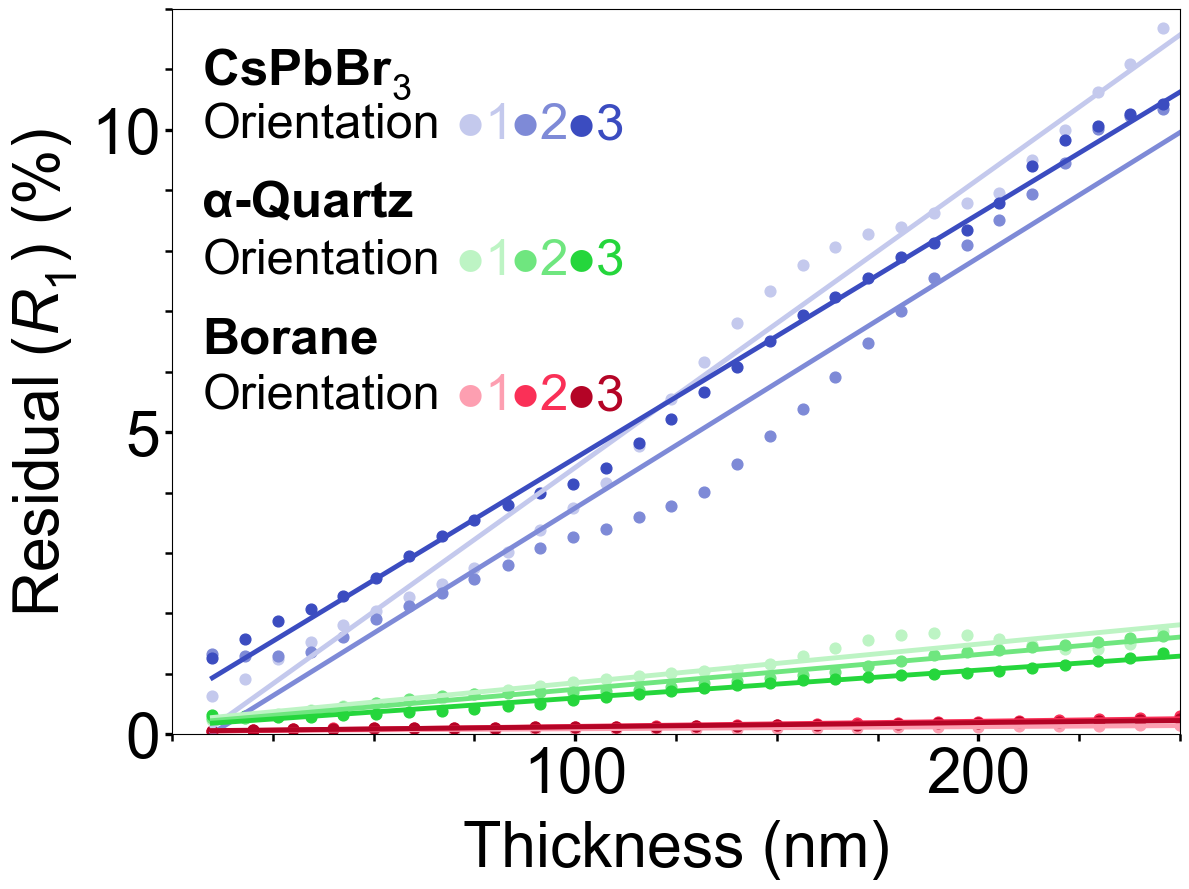

In [12]:
results = plot_global_only(
    {
        r"CsPbBr$_3$": {
            "folder": str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr_subset"),
            "orientations": [1,2,3],
            "cif_exp": str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/CsPbBr_P67-crot-050_dyn.cif_pets"),
        },
        r"α-Quartz": {
            "folder": str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/quartz"),
            "orientations": [1, 2, 3],
            "cif_exp": str(REPO_ROOT / "diffBloch_version_0.0.1/data/quartz/quartz.cif_pets"),
        },
        r"Borane": {
            "folder": str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/borane"),
            "orientations": [1,2,3],
            "cif_exp": str(REPO_ROOT / "diffBloch_version_0.0.1/data/borane/borane_dyn_final_16.cif_pets"),
        },
    },
    mode="global"
)


/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_11923/593981553.py:92: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


[INFO] Found 293 HKLs above 3σ for orientations=[1, 8, 19]
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr/no_abs_rotation_1_thickness_100_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr/param_rotation_1_thickness_100_intensities.csv
[INFO] After merge: (454, 9)
[FILTER] Applied |g| <= 10 Å⁻¹ → kept 454/454
[FILTER] Applied 3σ HKL filter → kept 29/454
[FILTER] Applied cutoff=1e-08, kept 29/29 rows
[RESULT] Global R=0.006369, Scale=1.000000
[LOAD] no_abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr/no_abs_rotation_1_thickness_140_intensities.csv, abs=absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr/param_rotation_1_thickness_140_intensities.csv
[INFO] After merge: (454, 9)
[FILTER] Applied |g| <= 10 Å⁻¹ → kept 454/454
[FILTER] Applied 3σ HKL filter → kept 29/454
[FILTER] Applied cutoff=1e-08, kept 29/29 rows
[RESULT] Global R=0.007720, Scal

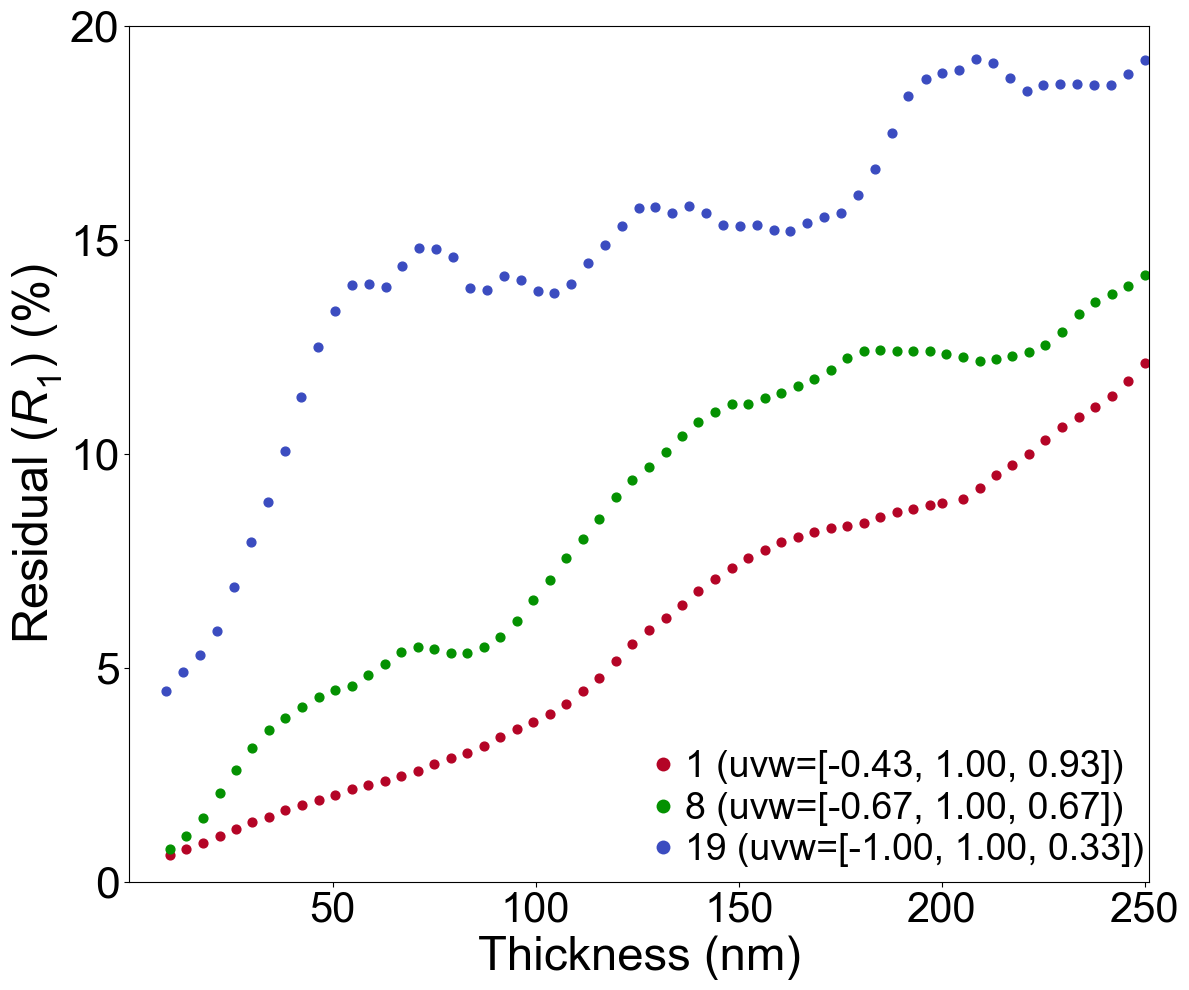

In [13]:
COLOR_MAP = {1: "#b40426", 8: "#049101", 19: "#3b4cc0"}
DEFAULT_COLOR = "#777777"

def parse_hkl_str(s):
    s = str(s).strip().strip("()[]").replace(",", " ")
    parts = [p for p in s.split() if p]
    return tuple(int(x) for x in parts) if len(parts) == 3 else None

def plot_global_only(
    folders,
    cutoff=1e-8,
    save_summary=None,
    orientations=None,
    g_cutoff=10,
    hkls_filter=None,
    orientation_labels=None,
    orientation_uvws=None
):
    results_map = {}
    for folder in folders:
        df = process_and_collect_global_only(
            folder,
            cutoff=cutoff,
            orientations=orientations,
            hkls_filter=hkls_filter,
            g_cutoff=g_cutoff,
        )

        if "G-vector Length" in df.columns:
            df = df[df["G-vector Length"] <= g_cutoff].copy()

        results_map[os.path.basename(folder)] = df

    if all(df.empty for df in results_map.values()):
        print("[warn] All datasets empty after filtering.")
        return results_map

    plt.figure(figsize=(12, 10))
    legend_handles = []

    for label, df in results_map.items():
        if df.empty:
            continue
        for j, (rot, df_rot) in enumerate(df.groupby("Rotation")):
            name = orientation_labels.get(rot, f"Orientation {rot}") if orientation_labels else f"{rot}"
            if orientation_uvws and rot in orientation_uvws:
                name = f"{name} (uvw={orientation_uvws[rot]})"
            color = COLOR_MAP.get(rot, DEFAULT_COLOR)

            x_nm = (df_rot["Thickness"] / 10.0).values.reshape(-1, 1)
            y = (100 * df_rot["Global_R"]).values

            # scatter only (no line fit)
            plt.scatter(x_nm, y, color=color, s=40, marker="o")

            legend_handles.append(Line2D(
                [0],[0], marker="o", color="none",
                markerfacecolor=color, markeredgecolor="none", markersize=10, label=name
            ))

    plt.xlabel("Thickness (nm)", fontsize=34)
    plt.ylabel(r"Residual ($R_1$) (%)", fontsize=35)
    plt.xticks([50, 100, 150, 200, 250], fontsize=30)
    plt.yticks(fontsize=32)
    plt.yticks([0,5,10,15,20], fontsize=32)

    plt.xlim(0, 251)
    plt.ylim(0, 20)
    plt.legend(
        handles=legend_handles,
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(1.01, 0.00),
        fontsize=27,
        handlelength=0.8,
        handletextpad=0.2,
        labelspacing=0.2,
        borderaxespad=0.00
    )
    plt.tight_layout()
    plt.show()

    if save_summary:
        for label, df in results_map.items():
            out = Path(save_summary).with_name(f"{label}_{Path(save_summary).name}")
            df.to_csv(out, index=False)

    return results_map

# Example call
hkls_filter = get_hkls_above_3sigma(
    str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/CsPbBr_P67-crot-050_dyn.cif_pets"),
    orientations=[1, 8, 19]
)
orientation_labels = {1: "1", 8: "8", 19: "19"}
orientation_uvws = {
    1: "[-0.43, 1.00, 0.93]",
    8: "[-0.67, 1.00, 0.67]",
    19: "[-1.00, 1.00, 0.33]",
}

results = plot_global_only(
    folders=[str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr")],
    cutoff=1e-8,
    orientations=[1, 8, 19],
    hkls_filter=hkls_filter,
    g_cutoff=10,
    orientation_labels=orientation_labels,
    orientation_uvws=orientation_uvws
)
